# Analysis of perturbing and Doppler-Broadening cross sections

In [1]:
import sandy
import pandas as pd

Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


In [2]:
import matplotlib.pyplot as plt

# Create perturbed PENDF XS

## Retrieve ENDF-6 file

In [3]:
tape = sandy.get_endf6_file("endfb_80", "xs", 942390)

In [4]:
pendf = tape.get_pendf(err=0.001)
xs = sandy.Xs.from_endf6(pendf)

    If you want to process 0K cross sections use `temperature=0.1`.
    


## Extract cross sections and perturb after RECONR

In [5]:
pert_coeff = 1
ipert = 25

egrid = sandy.energy_grids.SCALE238
estart = egrid[ipert]
estop = egrid[ipert+1]

pert = sandy.Pert([1, 1 + pert_coeff], index=[estart, estop])

print(
    f"""
Perturb fission xs in range ({estart}, {estop}) eV by a factor {pert_coeff*100} %.
Perturbation object is:
{pert}
"""
 )


Perturb fission xs in range (0.175, 0.19999999999999998) eV by a factor 100 %.
Perturbation object is:
ENERGY
(0.0, 0.175]                   1.00000e+00
(0.175, 0.19999999999999998]   2.00000e+00
dtype: float64



In [6]:
mat = tape.mat[0]
mt = 18

xspert = xs.custom_perturbation(mat, mt, pert)

## Analyize how the perturbation was implemented

In [7]:
def apply_mask(xs, estart, estop):
    mask = (xs.data.index >= estart) & (xs.data.index <= estop)
    return xs.data.loc[mask]

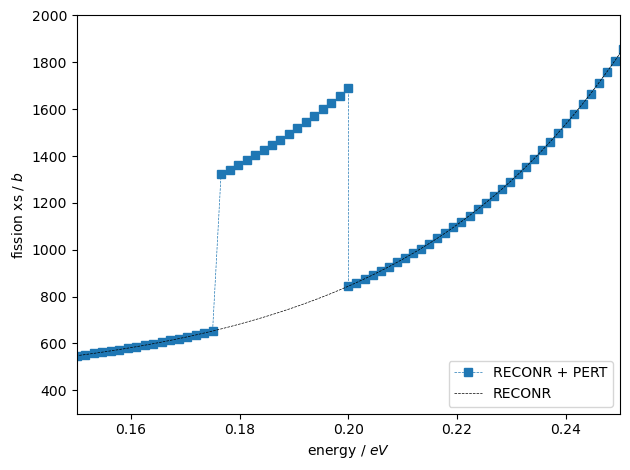

In [8]:
fig, ax = plt.subplots()

ax = xspert.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + PERT")

ax = xs.data[mat, mt].plot(ls="--", lw=.5, c="k", ax=ax, label=f"RECONR")

ax.set(xlim=(0.15, 0.25), ylim=(300, 2000), xlabel='energy / $eV$', ylabel="fission xs / $b$")
ax.legend(loc=4)

fig.tight_layout()

## Write PENDF files

In [11]:
pendf.to_file("pendffile")

pendfpert = xspert.to_endf6(pendf).update_intro()
pendfpert.to_file("pert_pendffile")

## Doppler-Broaden (BROADR) original and perturbed files

In [13]:
broadr = tape.get_pendf(
    pendftape="pendffile",
    err=0.001,
    temperature=900,
    heatr=False, purr=False, groupr=False, thermr=False, gaspr=False,
)

broadrpert = tape.get_pendf(
    pendftape="pert_pendffile",
    err=0.001,
    temperature=900,
    heatr=False, purr=False, groupr=False, thermr=False, gaspr=False,
)

## Extract and plot cross sections

In [14]:
xsbroadr = sandy.Xs.from_endf6(broadr)
xsbroadrpert = sandy.Xs.from_endf6(broadrpert)

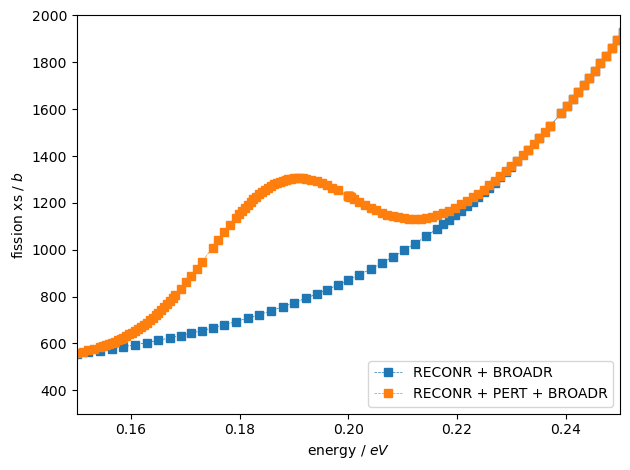

In [15]:
fig, ax = plt.subplots()

ax = xsbroadr.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + BROADR")

ax = xsbroadrpert.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + PERT + BROADR")

ax.set(xlim=(0.15, 0.25), ylim=(300, 2000), xlabel='energy / $eV$', ylabel="fission xs / $b$")
ax.legend(loc=4)

fig.tight_layout()

## Quick fix: apply perturbation after BROADR

In [18]:
xsbroadrpert_fix = xsbroadr.custom_perturbation(mat, mt, pert)

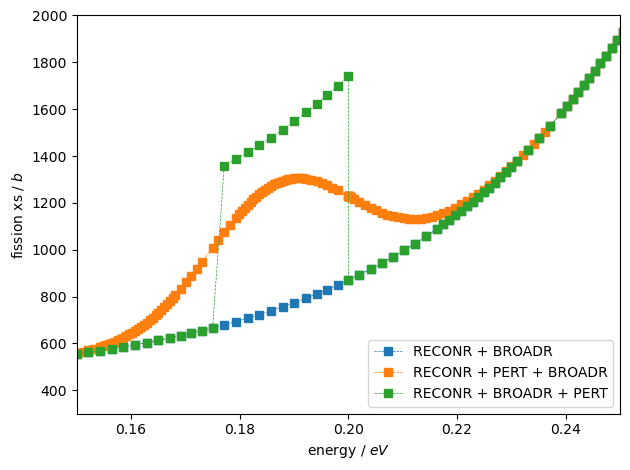

In [19]:
fig, ax = plt.subplots()

ax = xsbroadr.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + BROADR")

ax = xsbroadrpert.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + PERT + BROADR")

ax = xsbroadrpert_fix.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + BROADR + PERT")

ax.set(xlim=(0.15, 0.25), ylim=(300, 2000), xlabel='energy / $eV$', ylabel="fission xs / $b$")
ax.legend(loc=4)

fig.tight_layout()

## Get an ACE file with the quick fix

In [23]:
ace = tape.get_ace(
    pendf=broadrpert_fix,
    err=0.001,
    temperature=900,
    broadr=False,
    heatr=False, purr=False, groupr=False, thermr=False, gaspr=False,
    verbose=True,
)

 - Dumping NJOY input file to output stream...
moder
20 -21 /
moder
99 -22 /
broadr
-21 -22 -23 /
9437 1 0 0 0. /
0.001 /
900.0 /
0 /
moder
-23 30 /
acer
-21 -23 0 50 70 /
1 0 1 .09 0 /
'sandy runs acer'/
9437 900.0 /
1 1 /
/
stop


## Conclusions

When applying perturbations to a PENDF file **after RECONR**, but **before BROADR** (default SANDY implementation), the perturbation is effectively treatened as a resonance of the cross section and it is smoothened out by BROADR. 

An arguably more correct way is to apply the perturbation after doppler-broadening the cross sections (as explained above).